In [31]:
## Import Library 
import pandas as pd
import joblib
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay


from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [32]:
## Melakukan Load Data
def load_data():
    df = pd.read_csv("../data/online_shoppers_intention.csv")
    return df

# Panggil fungsi tanpa memasukkan parameter/argumen apa pun
df = load_data()
print("Dataset Loaded Successfully")
print(f"Dataset Shape : {df.shape}")

# Menampilkan 5 baris pertama data
df.head()

Dataset Loaded Successfully
Dataset Shape : (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [33]:
##  Data Preprocessing

print("=== CHECKING MISSING VALUES ===")

missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print(missing_values)
print(f"\nTotal Missing Values: {total_missing}")

if total_missing == 0:
    print("No missing values found.")
else:
    print("Missing values detected.")

# Salin dataframe untuk menghindari SettingWithCopyWarning
df_clean = df.copy()

# Encode Month
month_encoder = LabelEncoder()
df_clean["Month"] = month_encoder.fit_transform(df_clean["Month"])

# Encode VisitorType
visitor_encoder = LabelEncoder()
df_clean["VisitorType"] = visitor_encoder.fit_transform(df_clean["VisitorType"])

# Convert boolean columns
df_clean["Weekend"] = df_clean["Weekend"].astype(int)
df_clean["Revenue"] = df_clean["Revenue"].astype(int)

print("\nPreprocessing completed successfully.")

# Cek hasil preprocessing
df_clean.head()

=== CHECKING MISSING VALUES ===
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total Missing Values: 0
No missing values found.

Preprocessing completed successfully.


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [34]:
##Pemisahan Fitur & Target

X = df_clean.drop(columns=["Revenue"])
y = df_clean["Revenue"]

# Cek dimensi fitur dan target
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12330, 17)
y shape: (12330,)


In [35]:
## Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

Train Shape : (9864, 17)
Test Shape  : (2466, 17)


In [36]:
## Melakuakan Evaluasi Model

def evaluate_model(model, X_test_eval, y_test_eval):
    predictions = model.predict(X_test_eval)
    
    accuracy = accuracy_score(y_test_eval, predictions)
    precision = precision_score(y_test_eval, predictions)
    recall = recall_score(y_test_eval, predictions)
    f1 = f1_score(y_test_eval, predictions)
    
    return accuracy, precision, recall, f1, predictions

In [37]:
## Standarisasi Data (Logistic Regression)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization applied successfully.")

Standardization applied successfully.


In [38]:
## Melatih Logistic Regression

print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_acc, lr_precision, lr_recall, lr_f1, _ = evaluate_model(lr_model, X_test_scaled, y_test)

print("\nLOGISTIC REGRESSION RESULT")
print(f"Accuracy  : {lr_acc:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

Training Logistic Regression...

LOGISTIC REGRESSION RESULT
Accuracy  : 0.8832
Precision : 0.7640
Recall    : 0.3560
F1 Score  : 0.4857


In [39]:
## Melatih Random Forest

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)

rf_acc, rf_precision, rf_recall, rf_f1, _ = evaluate_model(rf_model, X_test, y_test)

print("\nRANDOM FOREST RESULT")
print(f"Accuracy  : {rf_acc:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Training Random Forest...



RANDOM FOREST RESULT
Accuracy  : 0.8962
Precision : 0.7500
Recall    : 0.4948
F1 Score  : 0.5962


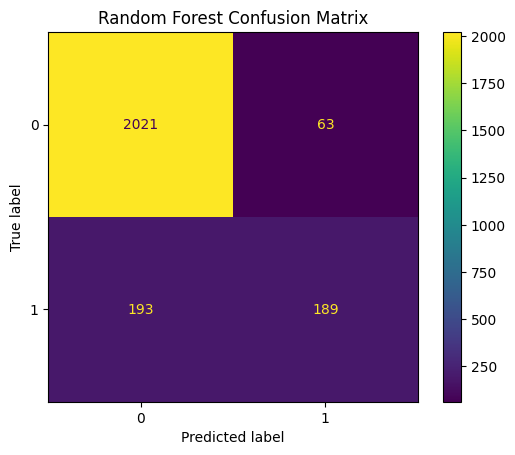

In [40]:
## Visualisasi Confusion Matrix untuk Random Forest
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [41]:
## Melakukan Hyperparameter Tuning

print("Running Hyperparameter Tuning...")

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

tuned_acc, tuned_precision, tuned_recall, tuned_f1, predictions = evaluate_model(
    best_model, X_test, y_test
)

print("BEST PARAMETERS:")
print(grid_search.best_params_)

print("\nOPTIMIZED MODEL RESULT")
print(f"Accuracy  : {tuned_acc:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")

Running Hyperparameter Tuning...
BEST PARAMETERS:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

OPTIMIZED MODEL RESULT
Accuracy  : 0.8735
Precision : 0.5703
Recall    : 0.7435
F1 Score  : 0.6455


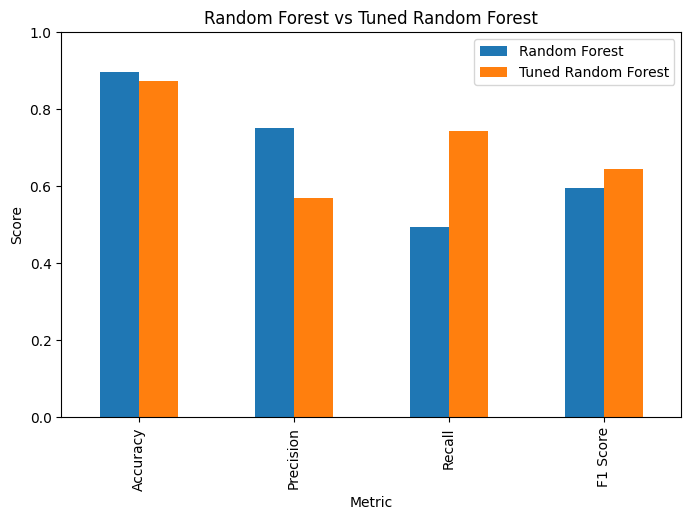

In [42]:
## Visualisasi perbandingan performa model Random Forest sebelum dan sesudah hyperparameter tuning

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Random Forest": [
        rf_acc,
        rf_precision,
        rf_recall,
        rf_f1
    ],
    "Tuned Random Forest": [
        tuned_acc,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Random Forest vs Tuned Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.show()

In [43]:

# 1. Melakukan prediksi menggunakan data uji
predictions = best_model.predict(X_test)

# 2. Menampilkan laporan klasifikasi dalam bentuk teks
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, predictions))

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92      2084
           1       0.57      0.74      0.65       382

    accuracy                           0.87      2466
   macro avg       0.76      0.82      0.78      2466
weighted avg       0.89      0.87      0.88      2466



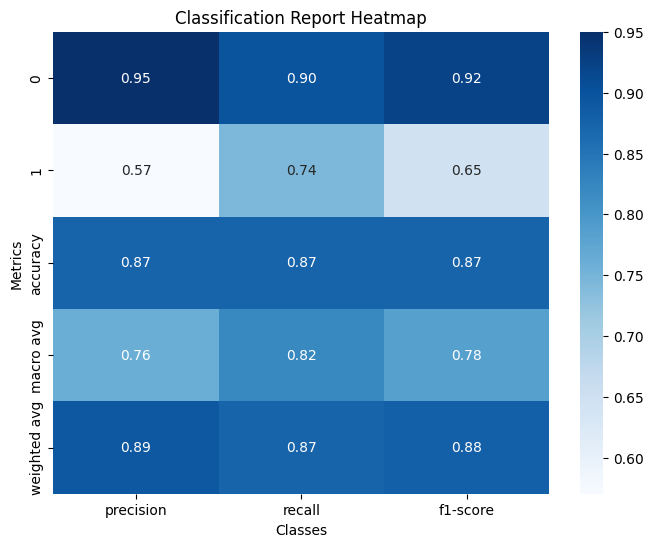

In [44]:
# Mengubah classification report ke dalam bentuk dataframe
report_dict = classification_report(y_test, predictions, output_dict=True)
# Mengambil hanya nilai precision, recall, f1-score (mengabaikan support)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T 

# Membuat visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(report_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.ylabel("Metrics")
plt.xlabel("Classes")
plt.show()

In [45]:
## melihat 10 fitur atau variabel yang paling berpengaruh dalam menentukan keputusan model Random Forest

print("TOP 10 IMPORTANsT FEATURES:")
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

# Mengurutkan dari yang paling penting ke yang tidak penting
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Menampilkan 10 besar dalam bentuk tabel ringkas
top_10 = importance_df.head(10)
print(top_10)

TOP 10 IMPORTANsT FEATURES:
                    Feature  Importance
8                PageValues    0.518179
5   ProductRelated_Duration    0.083842
7                 ExitRates    0.075338
10                    Month    0.065924
4            ProductRelated    0.056159
6               BounceRates    0.050540
1   Administrative_Duration    0.036658
0            Administrative    0.022298
14              TrafficType    0.016716
3    Informational_Duration    0.014248


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9712\1442584238.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_10, palette="viridis")


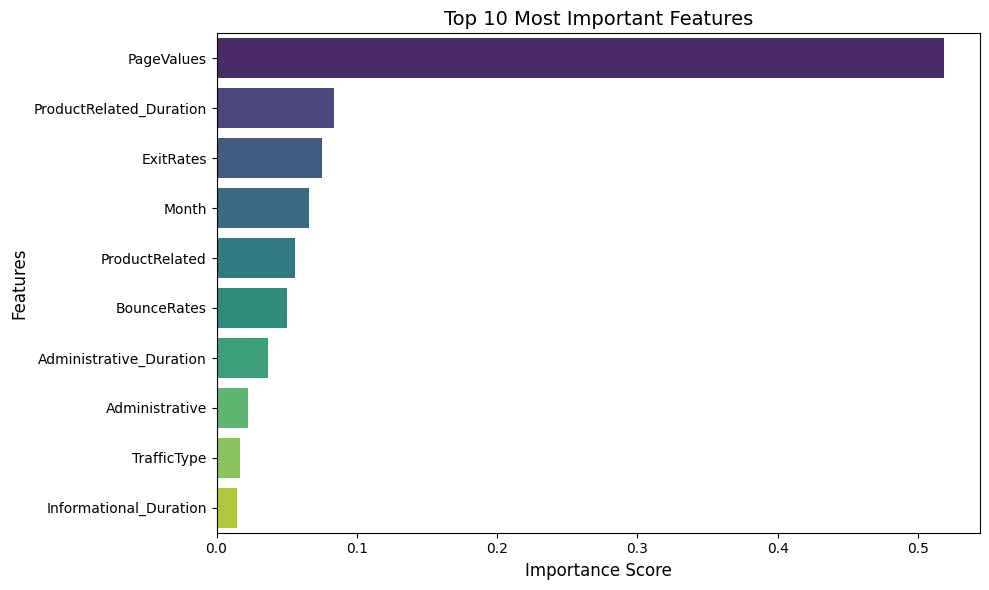

In [46]:
## memvisualisasikan 10 fitur teratas yang paling berpengaruh

plt.figure(figsize=(10, 6))

# Membuat barplot horizontal untuk 10 fitur teratas
sns.barplot(x="Importance", y="Feature", data=top_10, palette="viridis")

plt.title("Top 10 Most Important Features", fontsize=14)
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [48]:

os.makedirs("../models", exist_ok=True)

# Simpan model dan encoder menggunakan path relatif '../models/...'
joblib.dump(best_model, "../models/purchase_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(month_encoder, "../models/month_encoder.pkl")
joblib.dump(visitor_encoder, "../models/visitor_encoder.pkl")

print("All models, scaler, and encoders saved successfully!")

All models, scaler, and encoders saved successfully!
